In [1]:
#imports
import sys
sys.path.append("../../src")
# A collection of handy imports. Not that important.
from common_imports import * 
import numerical_quenches as nq
import kibble_zurek as kz
import time_evolved_z_correlators as zz
#
from numerical_quenches import g_linear_hold


In [2]:
def g_sudden_quench(t,args):
    g0,gf,t0 = args
    if t<t0:
        return g0
    else:
        return gf


def critical_times(gf,n):
    ek = 2*sqrt(gf**2+1)
    n_plot = np.arange(0,n)
    tns = (n_plot+1/2)*pi/ek
    return tns


Text(0, 0.5, 'g')

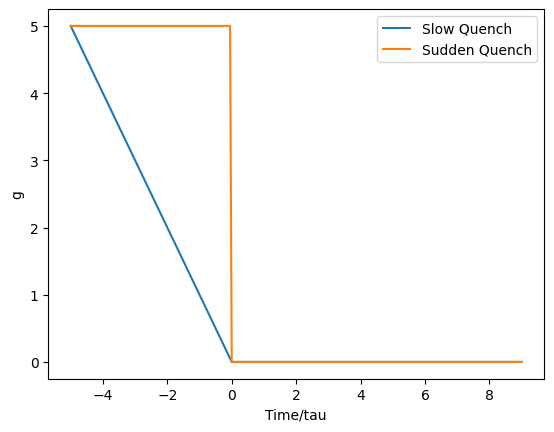

In [171]:
tau = 10
L = 100
t_eval = np.linspace(-4*tau, 100, 250)
t_eval = np.unique(np.sort(np.append(t_eval, tau)))

slow_args = [tau,tau]
g0 = g_linear_hold(t_eval[0],slow_args)
gf = g_linear_hold(t_eval[-1],slow_args)
sudden_args=[g0,gf,tau]

plot((t_eval-tau)/tau, [g_linear_hold(ti,slow_args) for ti in t_eval],label="Slow Quench")
plot((t_eval-tau)/tau, [g_sudden_quench(ti,sudden_args) for ti in t_eval],label="Sudden Quench")
legend()
xlabel("Time/tau")
ylabel("g")

In [172]:
slow_states = nq.states(L,t_eval,g_linear_hold,slow_args)
sudden_states = nq.states(L,t_eval,g_sudden_quench,sudden_args)
tns = critical_times(gf,10)


5.0
5.0


In [173]:
ns = [1,2,3,4,5,6,7,8]
P1 = array([[zz.P_n(ni,s) for s in slow_states] for ni in ns])
P2 = array([[zz.P_n(ni,s) for s in sudden_states] for ni in ns])


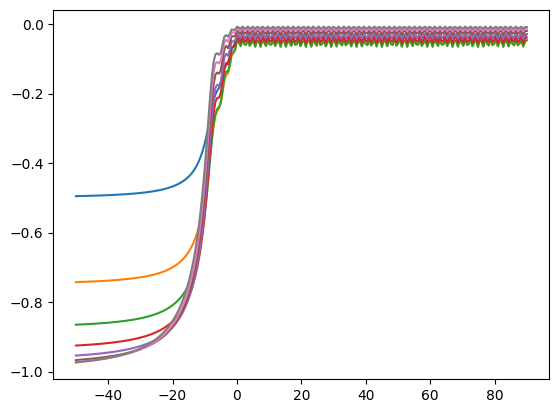

In [174]:
est_defects=[]
t_defects=[]
s_defects=[]
gals = []
for p1,p2,ni in zip(P1,P2,ns):
    t_plot = t_eval-tau
    est_defect = ni*(ni+1)/2**(ni-1)/ (sqrt(2*tau)*2*pi)/2
    time_average = abs(np.average(p1[t_plot>0]))
    sudden_avg = abs(np.average(p2[t_plot>0]))
    defect = abs(1/2**ni- time_average)
    est_defects.append(est_defect)
    t_defects.append(defect)
    s_defects.append(abs(sudden_avg-1/2**ni))
    gals.append(abs(1/2**ni- p1[t_plot==0]))

    plot(t_eval-tau,1/2**ni-p1)


    
    #show()
#xlim(-tau,tau)
gals = array(gals)
est_defects = array(est_defects)
t_defects = array(t_defects)
s_defects = array(s_defects)
#yscale("log")

Text(0, 0.5, '$\\delta$')

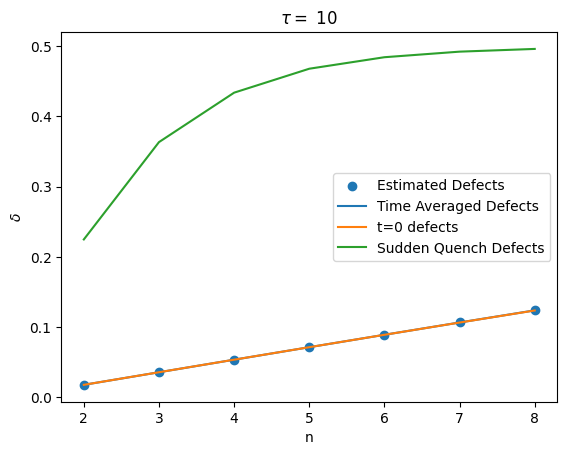

In [179]:
scatter(ns,est_defects,label="Estimated Defects")
plot(ns,t_defects,label="Time Averaged Defects")
plot(ns,gals,label="t=0 defects")
plot(ns,s_defects,label="Sudden Quench Defects")
legend()
title(rf"$\tau= $ {tau}")
xlabel("n")
ylabel(r"$\delta$")


In [176]:
ns = [2,3,4,5,6,7,8]
P1 = array([[kz.P_n(ni,s) for s in slow_states] for ni in ns])
P2 = array([[kz.P_n(ni,s) for s in sudden_states] for ni in ns])

#yscale("log")

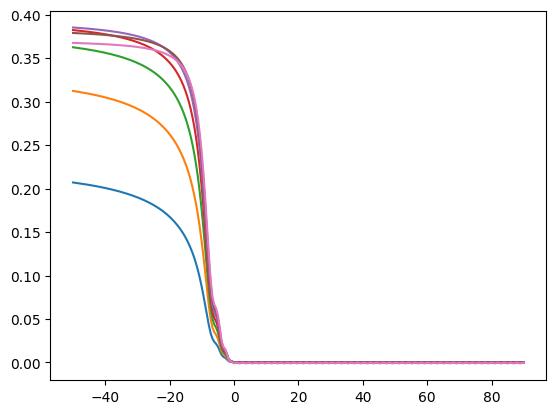

In [177]:
est_defects=[]
t_defects=[]
s_defects=[]
gals = []
for p1,p2,ni in zip(P1,P2,ns):
    t_plot = t_eval-tau
    est_defect = (ni-1)/ (sqrt(2*tau)*2*pi)/2
    time_average = abs(np.average(p1[t_plot>0]))
    sudden_avg = abs(np.average(p2[t_plot>0]))
    defect = abs(1/2- time_average)
    est_defects.append(est_defect)
    t_defects.append(defect)
    s_defects.append(abs(sudden_avg-1/2))
    gals.append(abs(1/2- p1[t_plot==0]))

    plot(t_eval-tau,1/2-p1-est_defect)


    
    #show()
#xlim(-tau,tau)
gals = array(gals)
est_defects = array(est_defects)
t_defects = array(t_defects)
s_defects = array(s_defects)

Text(0, 0.5, '$\\delta$')

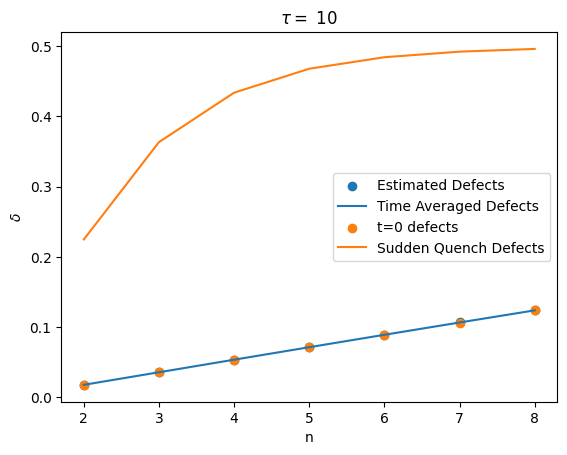

In [178]:
scatter(ns,est_defects,label="Estimated Defects")
plot(ns,t_defects,label="Time Averaged Defects")
scatter(ns,gals,label="t=0 defects")
plot(ns,s_defects,label="Sudden Quench Defects")
legend()
title(rf"$\tau= $ {tau}")
xlabel("n")
ylabel(r"$\delta$")